In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn as sk

import warnings 
warnings.filterwarnings("ignore")

# Part 1: Understanding the Dataset

In [2]:
df = pd.read_csv("train_and_test2.csv")

In [3]:
df.shape

(1309, 28)

In [4]:
df.info

<bound method DataFrame.info of       Passengerid   Age      Fare  Sex  sibsp  zero  zero.1  zero.2  zero.3  \
0               1  22.0    7.2500    0      1     0       0       0       0   
1               2  38.0   71.2833    1      1     0       0       0       0   
2               3  26.0    7.9250    1      0     0       0       0       0   
3               4  35.0   53.1000    1      1     0       0       0       0   
4               5  35.0    8.0500    0      0     0       0       0       0   
...           ...   ...       ...  ...    ...   ...     ...     ...     ...   
1304         1305  28.0    8.0500    0      0     0       0       0       0   
1305         1306  39.0  108.9000    1      0     0       0       0       0   
1306         1307  38.5    7.2500    0      0     0       0       0       0   
1307         1308  28.0    8.0500    0      0     0       0       0       0   
1308         1309  28.0   22.3583    0      1     0       0       0       0   

      zero.4  ...  

In [5]:
df.head(10)

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
5,6,28.0,8.4583,0,0,0,0,0,0,0,...,0,0,0,3,0,0,1.0,0,0,0
6,7,54.0,51.8625,0,0,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,0
7,8,2.0,21.0750,0,3,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
8,9,27.0,11.1333,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
9,10,14.0,30.0708,1,1,0,0,0,0,0,...,0,0,0,2,0,0,0.0,0,0,1


In [6]:
df.tail()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
1304,1305,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1305,1306,39.0,108.9000,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,0
1306,1307,38.5,7.2500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1307,1308,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1308,1309,28.0,22.3583,0,1,0,0,0,0,0,...,0,0,0,3,0,0,0.0,0,0,0


In [7]:
df.sample(5)

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
900,901,21.0,24.1500,0,2,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
701,702,35.0,26.2875,0,0,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
100,101,28.0,7.8958,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1165,1166,28.0,7.2250,0,0,0,0,0,0,0,...,0,0,0,3,0,0,0.0,0,0,0
574,575,16.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [8]:
df.describe()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,...,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1307.000000,1309.0,1309.0,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.294882,0.0,0.0,1.492731,0.0,0.0,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.837836,0.0,0.0,0.814626,0.0,0.0,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.000000,0.0,0.0,1.000000,0.0,0.0,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000


In [9]:
df.isnull().sum()

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1         0
zero.2         0
zero.3         0
zero.4         0
zero.5         0
zero.6         0
Parch          0
zero.7         0
zero.8         0
zero.9         0
zero.10        0
zero.11        0
zero.12        0
zero.13        0
zero.14        0
Pclass         0
zero.15        0
zero.16        0
Embarked       2
zero.17        0
zero.18        0
2urvived       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

Observations

1) Dataset consist of [1309 rows x 28 columns].
2) Dataset consist of zero columns, whose value for all rows is zero, we need to remove it.
3) All the categorical columns are aleready encoded.
4) We can observer that fair is positively skewed.
5) The name of column survived is misspelled to 2urvived.
6) Pclass is negatively skewed.
7) There are two null values in column Embarked.
8) There are no duplicate rows in dataset.

In [11]:
# Removing Zero columns from the dataset
cols_to_keep = [col for col in df.columns if 'zero' not in col]
df = df[cols_to_keep]

In [12]:
# Renaming 2urvived to Survived
df = df.rename(columns={'2urvived': 'Survived'})

----------------------------------------------------------------------------------------------------

# Part 2: Exploratory Data Analysis

In [37]:
df.head(10)

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0
5,6,28.0,8.4583,0,0,0,3,1.0,0
6,7,54.0,51.8625,0,0,0,1,2.0,0
7,8,2.0,21.0750,0,3,1,3,2.0,0
8,9,27.0,11.1333,1,0,2,3,2.0,1
9,10,14.0,30.0708,1,1,0,2,0.0,1


In [14]:
# Removing Null values from Embarked
df = df.dropna(subset=['Embarked'])

After checking for missing data, we observed that the Embarked column is only missing 2 values. Because this is such a statistically insignificant amount of data, it is safer to simply drop those two passenger records rather than guessing their boarding port.

We use subset=['Embarked'] inside the dropna() function to ensure we only drop rows if the Embarked data is missing. This protects passengers who might just be missing an Age or Cabin from being accidentally deleted!

In [15]:
df.duplicated().sum()

np.int64(0)

Text(0.5, 1.0, 'Hisplot for Survived')

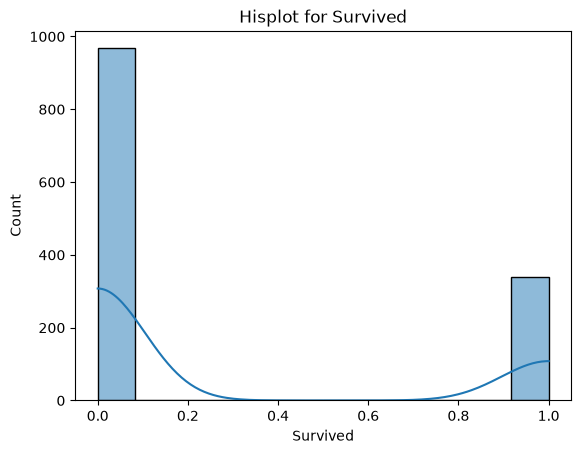

In [38]:
sns.histplot(data=df, x="Survived", kde= True)
plt.title("Hisplot for Survived")

Text(0.5, 1.0, 'Hisplot for Fare')

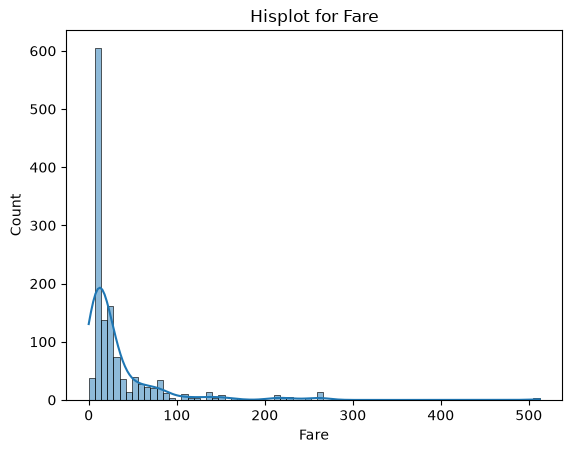

In [ ]:
sns.histplot(data=df, x="Fare", kde= True)
plt.title("Hisplot for Fare")

From above hisplot, we can clearly obsever that fare are positively skewed and certainly their outliers in it.

<Axes: xlabel='Sex', ylabel='count'>

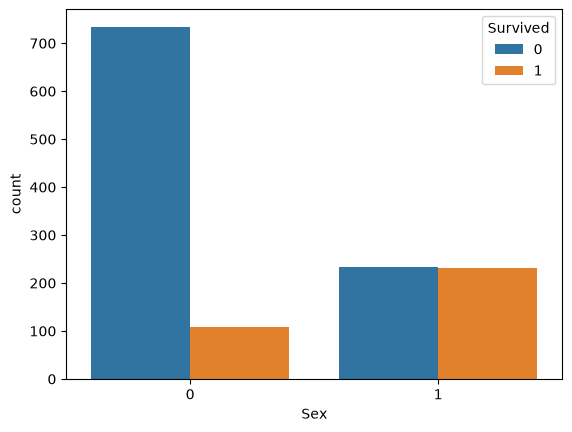

In [17]:
sns.countplot(data=df, x='Sex', hue='Survived')

The above chart clearly displays disparity between men and women survival rate, driven by the maritime "women and children first" protocol.

- Males (0): The large blue bar shows that the vast majority of men on board unfortunately did not  survive the disaster.
- Females (1): The orange bar dominates here, showing that a significant majority of women survived.

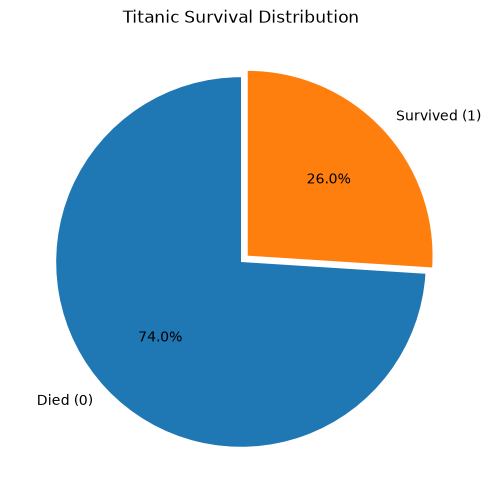

In [18]:
survival_counts = df['Survived'].value_counts()


plt.figure(figsize=(6, 6))
plt.pie(survival_counts, 
        labels=['Died (0)', 'Survived (1)'], 
        autopct='%1.1f%%', 
        startangle=90, 
        explode=[0, 0.05], 
        )

plt.title('Titanic Survival Distribution')
plt.show()

In above pie chart, by looking at the target variable (Survived), we can clearly see the overall survival rate:

- Died (0): The large blue slice shows that a massive majority (74.0%) of the passengers in this dataset did not survive.
- Survived (1): The separated orange slice highlights that only 26.0% of the passengers survived.

Text(0.5, 1.0, 'Survival by Ticket Class')

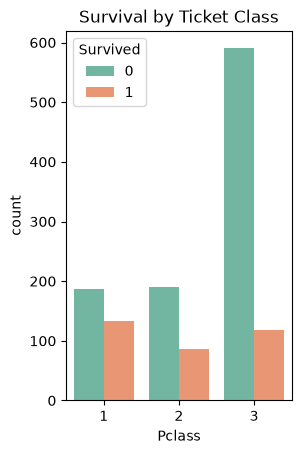

In [19]:
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set2')
plt.title('Survival by Ticket Class')

The above chart clearly shows that a passenger's ticket class (their socio-economic status) played a major role in their chances of surviving the disaster.

- 1st Class (1): This class had the highest orange bar, representing that first class people had highest survival rate.
- 2nd Class (2): The odds were slightly worse here, with more passengers dying than surviving.
- 3rd Class (3): The massive green bar reveals a tragic reality: the vast majority of 3rd class passengers did not survive.

<Axes: xlabel='Pclass', ylabel='Age'>

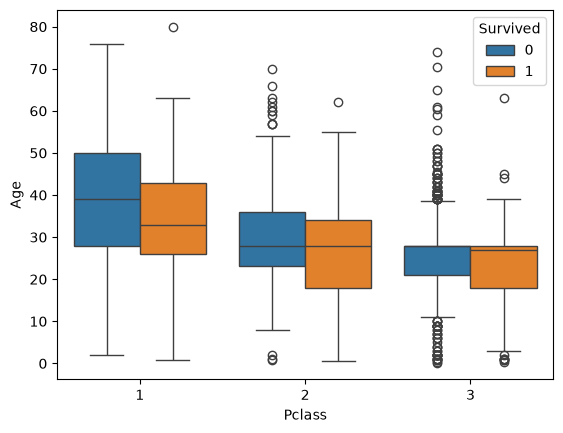

In [20]:
sns.boxplot(df,x='Pclass',y='Age',hue='Survived',)

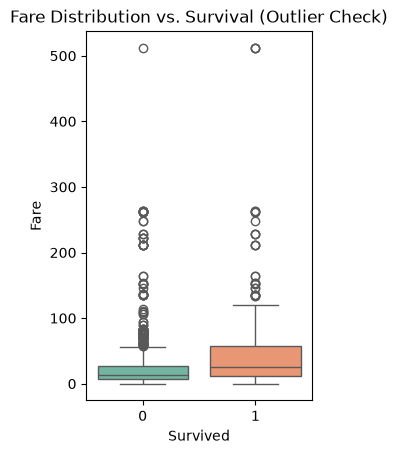

In [21]:
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Survived', y='Fare', palette='Set2')
plt.title('Fare Distribution vs. Survival (Outlier Check)')

plt.show()

The above boxplot helps us understand how fare influenced their survival.

- The Boxes: The colored boxes represent where the vast majority of passengers fall. We can see that the orange box (Survived) sits slightly higher than the green box (Died), meaning survivors generally paid higher fares.
- The Dots (Outliers): The black circles stretching all the way up to $500 are extreme outliers. These were incredibly wealthy passengers who paid massive premiums for their tickets.

<Axes: xlabel='Fare', ylabel='Age'>

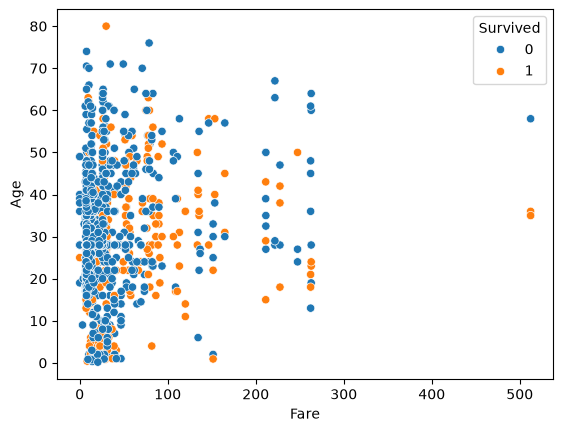

In [22]:
sns.scatterplot(df,x='Fare',y='Age',hue='Survived')

Text(0.5, 0, 'Age')

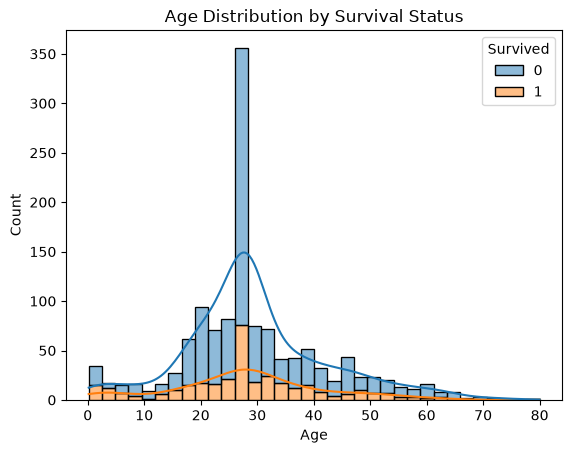

In [23]:
sns.histplot(data=df, x='Age', hue='Survived', kde=True, multiple='stack')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')


The histogram provides a deep look into the age demographics on titanic and how age influenced the survival rate.

- Infants & Children (Ages 0-10): We can clearly see a bump between age group 0-10, showing a significant number of childrens survived, mathematically confirming the strict enforcement of the "women and children first" maritime protocol.
- Young Adults (Ages 20-30): This age group formed the massive majority of the ship's population. However, the towering blue peak indicates that the highest concentration of casualties also occurred within this demographic.
- The KDE Curves: The smooth lines tracking over the bars (Kernel Density Estimate) help us visualize the overall shape and density of the data without getting distracted by the exact count of a single age bar.

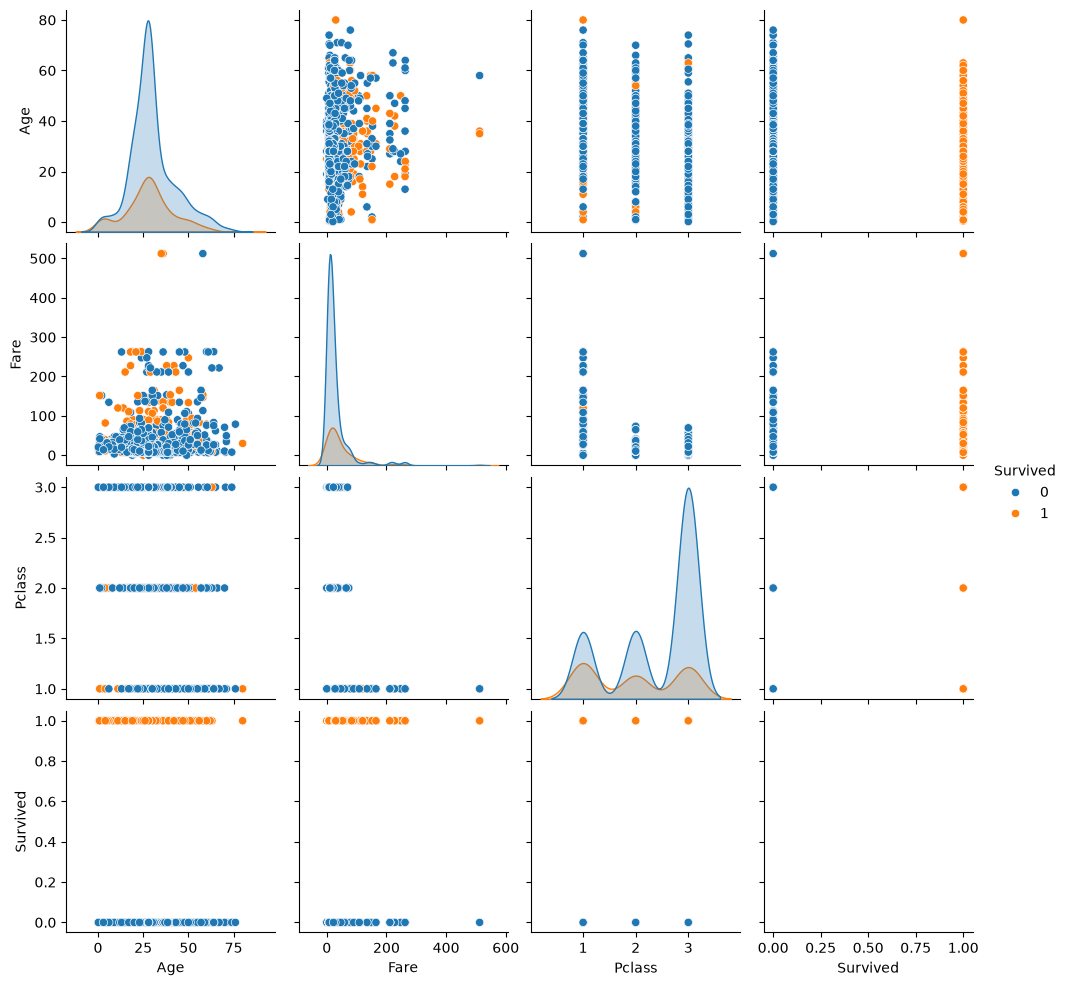

In [24]:
cols = ['Age', 'Fare', 'Pclass', 'Survived']
sns.pairplot(df, vars=cols, hue='Survived')

Text(0.5, 1.0, 'Titanic Feature Correlation Heatmap')

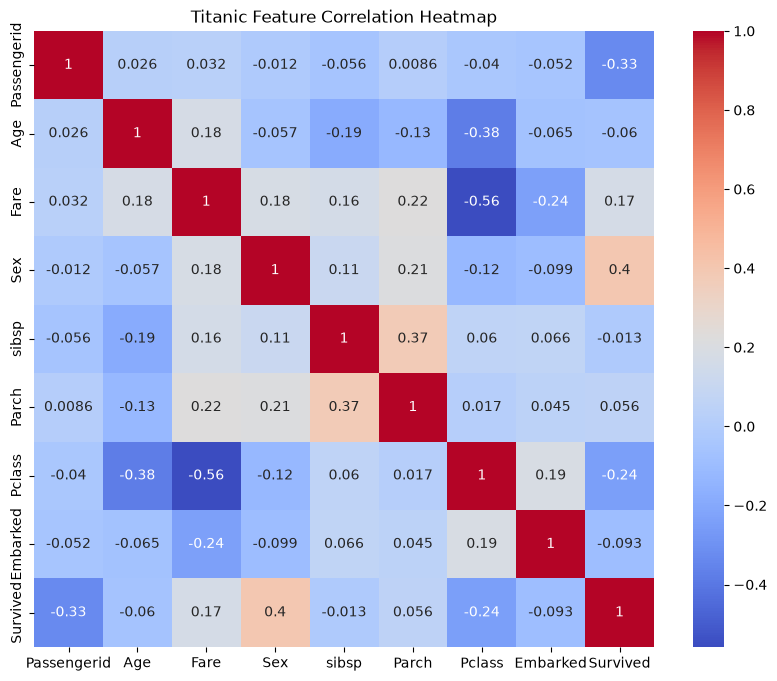

In [25]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True,
    cmap="coolwarm"
)
plt.title('Titanic Feature Correlation Heatmap')

The above heatmap gives us the correlation between different features in data set.

Key observations : 
- Sex vs. Survived (0.37): This is the strongest positive correlation with survival on the board. (Assuming females were encoded as 1 and males as 0, this mathematically confirms that being female greatly increased survival chances).
- Pclass vs. Fare (-0.56): The strongest relationship overall. The dark blue negative score makes perfect sense: as the class number gets smaller (going from 3rd class down to 1st class), the ticket price goes up.
- Pclass vs. Survived (-0.23): A solid negative correlation. As the class number increases (meaning lower socio-economic status), the chance of survival decreases.
- Age vs. Pclass (-0.38): An interesting background detail! Older passengers tended to have smaller class numbers, meaning older people were much more likely to be wealthy 1st-class passengers.

----------------------------------------------------------------------------------------------------

# Part 3: Data Preprocessing 

In [26]:
df.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass',
       'Embarked', 'Survived'],
      dtype='str')

In [27]:
X = df[['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass',
       'Embarked']] 
y = df['Survived']

Train_test_Split : A train-test split is a fundamental machine learning technique that divides your dataset into two subsets: a training set used to teach the model patterns, and a testing set used to evaluate its performance on unseen data.

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

StnadardScaler : to center numerical features around a mean of zero and scale them to a standard deviation of one, ensuring equal feature contribution, faster gradient descent convergence, and unbiased model regularization.

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

----------------------------------------------------------------------------------------------------

# Part 4: Logistic Regression Model 

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [31]:
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [32]:
y_pred = model.predict(X_test_scaled)

y_pred

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0])

In [33]:
model.intercept_

array([-1.63858838])

In [34]:
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient", key=abs, ascending=False)

coefficients

,feature,coefficient
0,Passengerid,-1.190506
3,Sex,1.070612
6,Pclass,-0.795319
1,Age,-0.403090
4,sibsp,-0.288025
7,Embarked,-0.082728
2,Fare,0.030080
5,Parch,-0.003781


Interpreting Coefficients: 

- Sex = 1.070612 ==> strong positive effect.
- Passengerid = -1.190506 ==> It has minimal or no effect on survival.
- Pclass = -0.795319 ==> Lower class usually means lower chance of survival.
- Age = -0.403090 ==> older passengers had lower survival odds.
- sibsp = -0.288025 ==> having more siblings aboard slightly lowers survival odds.
- Embarked = -0.082728 ==> very minimal effect, it can be ignored and had no effect on model.
- Fare = 0.030080 ==> small positive effect, meaning higher fare slightly increases survival odds.
- Parch = -0.003781 ==> almost zero effect, so it contributes very little.

The strongest useful predictors here are Sex, Pclass, and Age.

----------------------------------------------------------------------------------------------------

# Part 5: Model Evaluation

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='binary') 
recall = recall_score(y_test, y_pred, average='binary')
precision = precision_score(y_test, y_pred, average='binary')

print("Accuracy:", acc * 100)
print("Confusion Matrix:\n", cm)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)
print("Classification Report:\n", report)

Accuracy: 83.20610687022901
Confusion Matrix:
 [[182  10]
 [ 34  36]]
F1 Score: 0.6206896551724138
Recall: 0.5142857142857142
Precision: 0.782608695652174
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.95      0.89       192
           1       0.78      0.51      0.62        70

    accuracy                           0.83       262
   macro avg       0.81      0.73      0.76       262
weighted avg       0.83      0.83      0.82       262



F1 metric is more important for this dataset, as Titanic survival dataset is usually imbalanced because fewer passengers survived than did not, In imbalanced data, accuracy can look good even when the model misses many survivors, but F1 shows whether the model is actually doing a good job on the survivor class.